<a href="https://colab.research.google.com/github/abiduldul/Numerical-Method/blob/main/Materi%204/Newton_Interpolation_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INTERPOLASI NEWTON (Divided Difference)
Data titik:
  (0, 1)
  (1, 3)
  (2, 2)
  (3, 5)
  (4, 4)

Langkah 1: Menghitung tabel divided difference
  Kolom ke-1: [ 2. -1.  3. -1.]
  Kolom ke-2: [-1.5  2.  -2. ]
  Kolom ke-3: [ 1.16666667 -1.33333333]
  Kolom ke-4: [-0.625]

Langkah 2: Koefisien polinomial Newton:
  a_0 = 1.0
  a_1 = 2.0
  a_2 = -1.5
  a_3 = 1.1666666666666667
  a_4 = -0.625

Langkah 3: Menyusun polinomial Newton:
  P_1(x) = 2.0*x + 1.0
  P_2(x) = -1.5*x**2 + 3.5*x + 1.0
  P_3(x) = 1.16666666666667*x**3 - 5.0*x**2 + 5.83333333333333*x + 1.0
  P_4(x) = -0.625*x**4 + 4.91666666666667*x**3 - 11.875*x**2 + 9.58333333333333*x + 1.0

Hasil akhir polinomial Newton:
  P(x) = -0.625*x**4 + 4.91666666666667*x**3 - 11.875*x**2 + 9.58333333333333*x + 1.0


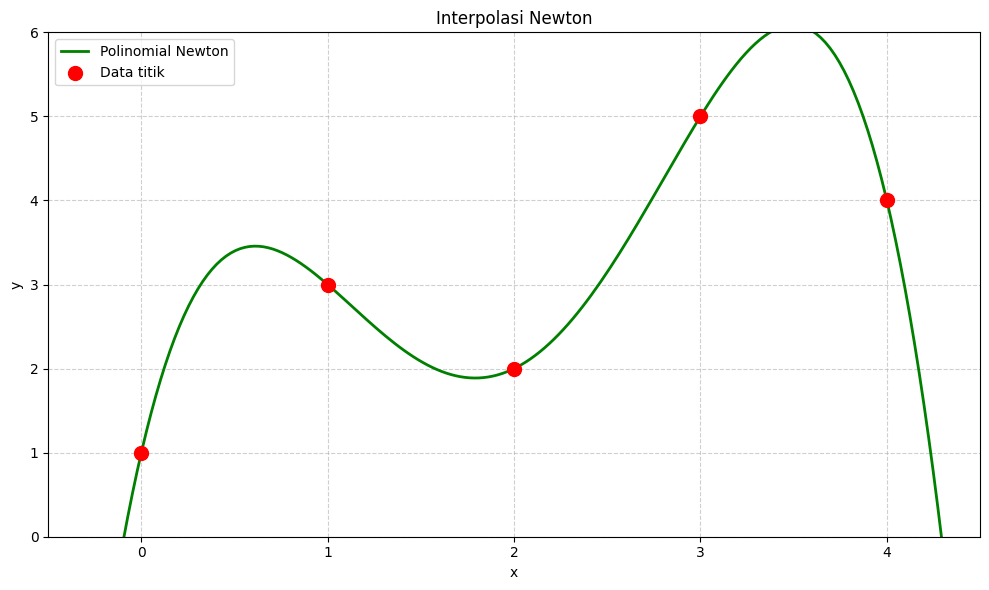

In [1]:
"""
Interpolasi Newton - Langkah demi langkah (Divided Difference)
Data: (0,1), (1,3), (2,2), (3,5), (4,4)
"""

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Data titik
x_points = np.array([0, 1, 2, 3, 4])
y_points = np.array([1, 3, 2, 5, 4])
n = len(x_points)

print("=" * 60)
print("INTERPOLASI NEWTON (Divided Difference)")
print("=" * 60)
print("Data titik:")
for i in range(n):
    print(f"  ({x_points[i]}, {y_points[i]})")
print()

# Membuat tabel divided difference
dd = np.zeros((n, n))
dd[:, 0] = y_points

print("Langkah 1: Menghitung tabel divided difference")
for j in range(1, n):
    for i in range(n - j):
        dd[i, j] = (dd[i+1, j-1] - dd[i, j-1]) / (x_points[i+j] - x_points[i])
    print(f"  Kolom ke-{j}: {dd[:n-j, j]}")

# Tampilkan koefisien
coeffs = dd[0, :]  # f[x0], f[x0,x1], f[x0,x1,x2], ...
print("\nLangkah 2: Koefisien polinomial Newton:")
for k in range(n):
    print(f"  a_{k} = {coeffs[k]}")

# Bentuk polinomial Newton secara simbolik
x_sym = sp.Symbol('x')
newton_poly = coeffs[0]
product = 1
print("\nLangkah 3: Menyusun polinomial Newton:")
for k in range(1, n):
    product *= (x_sym - x_points[k-1])
    newton_poly += coeffs[k] * product
    print(f"  P_{k}(x) = {sp.expand(newton_poly)}")

# Sederhanakan
newton_poly = sp.expand(newton_poly)
print(f"\nHasil akhir polinomial Newton:")
print(f"  P(x) = {newton_poly}")

# Fungsi evaluasi numerik menggunakan bentuk Newton (lebih stabil)
def newton_eval(x):
    result = coeffs[0]
    product = 1.0
    for k in range(1, n):
        product *= (x - x_points[k-1])
        result += coeffs[k] * product
    return result

# Plot
x_plot = np.linspace(-0.5, 4.5, 200)
y_plot = [newton_eval(x) for x in x_plot]

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, 'g-', label='Polinomial Newton', linewidth=2)
plt.scatter(x_points, y_points, color='red', s=100, zorder=5, label='Data titik')
plt.title('Interpolasi Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(-0.5, 4.5)
plt.ylim(min(y_points)-1, max(y_points)+1)
plt.tight_layout()
plt.show()